In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [12]:
train = pd.read_csv(r"C:\Users\91933\Downloads\HAR project\train.csv")
test = pd.read_csv(r"C:\Users\91933\Downloads\HAR project\test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (7352, 563)
Test shape: (2947, 563)


In [13]:
train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [14]:
print(train['Activity'].value_counts())

Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


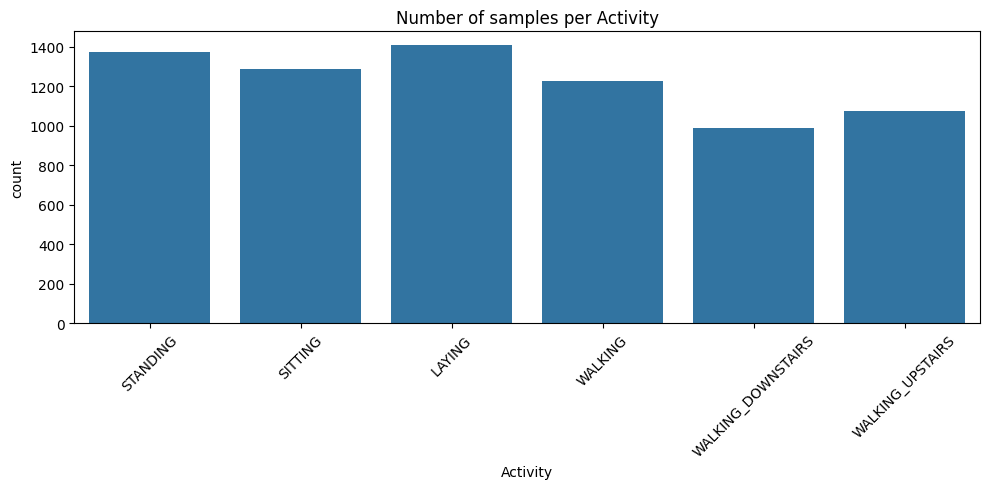

In [15]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Activity', data=train)
plt.title('Number of samples per Activity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
print("Missing values in train:", train.isnull().sum().sum())
print("Missing values in test:", test.isnull().sum().sum())

Missing values in train: 0
Missing values in test: 0


In [17]:
X_train = train.drop('Activity', axis=1)
y_train = train['Activity']

X_test = test.drop('Activity', axis=1)
y_test = test['Activity']

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (7352, 562)
y_train shape: (7352,)


In [18]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
print("Training... this will take ~1 minute")
model.fit(X_train, y_train)
print("Done! Model trained successfully!")

Training... this will take ~1 minute
Done! Model trained successfully!


In [19]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 92.67%


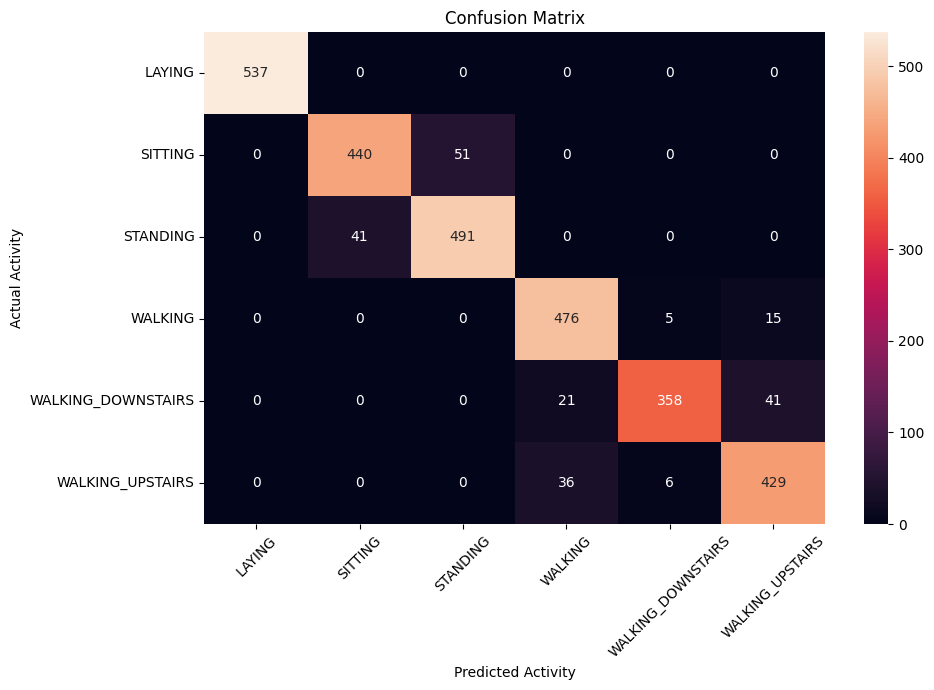

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual Activity')
plt.xlabel('Predicted Activity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.90      0.91       491
          STANDING       0.91      0.92      0.91       532
           WALKING       0.89      0.96      0.93       496
WALKING_DOWNSTAIRS       0.97      0.85      0.91       420
  WALKING_UPSTAIRS       0.88      0.91      0.90       471

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.93      0.93      2947



In [22]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)
print("Training SVM... this takes 2-3 minutes")
svm_model.fit(X_train, y_train)
print("Done!")

Training SVM... this takes 2-3 minutes
Done!


In [23]:
svm_pred = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)
print(f"SVM Accuracy: {svm_accuracy * 100:.2f}%")

SVM Accuracy: 93.08%


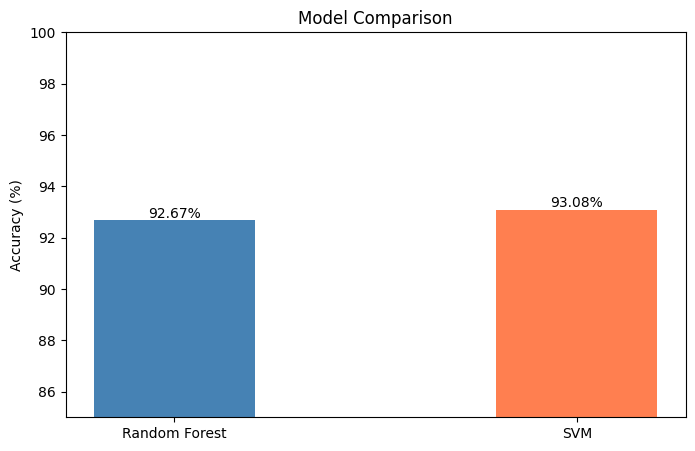

In [24]:
models = ['Random Forest', 'SVM']
accuracies = [accuracy * 100, svm_accuracy * 100]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['steelblue', 'coral'], width=0.4)
plt.ylim(85, 100)
plt.title('Model Comparison')
plt.ylabel('Accuracy (%)')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.1, 
             f'{acc:.2f}%', ha='center')
plt.show()

In [25]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("TensorFlow version:", tf.__version__)
print("Classes:", le.classes_)

TensorFlow version: 2.21.0
Classes: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


In [26]:
model_nn = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(6, activation='softmax')
])

model_nn.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])


C:\Users\91933\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
history = model_nn.fit(X_train, y_train_encoded,
                       epochs=20,
                       batch_size=32,
                       validation_split=0.2,
                       verbose=1)

Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6239 - loss: 0.8675 - val_accuracy: 0.9007 - val_loss: 0.3504
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8432 - loss: 0.3786 - val_accuracy: 0.9252 - val_loss: 0.2195
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8791 - loss: 0.2820 - val_accuracy: 0.9239 - val_loss: 0.1828
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9167 - loss: 0.2127 - val_accuracy: 0.9381 - val_loss: 0.1426
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9356 - loss: 0.1708 - val_accuracy: 0.9443 - val_loss: 0.1426
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9328 - loss: 0.1654 - val_accuracy: 0.9347 - val_loss: 0.1710
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9451 - loss: 0.1485 - val_accuracy: 0.9313 - val_loss: 0.2119
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9573 - loss: 0.1183 - val_accuracy: 0.

In [28]:
nn_loss, nn_accuracy = model_nn.evaluate(X_test, y_test_encoded, verbose=0)
print(f"Neural Network Accuracy: {nn_accuracy * 100:.2f}%")

Neural Network Accuracy: 92.47%


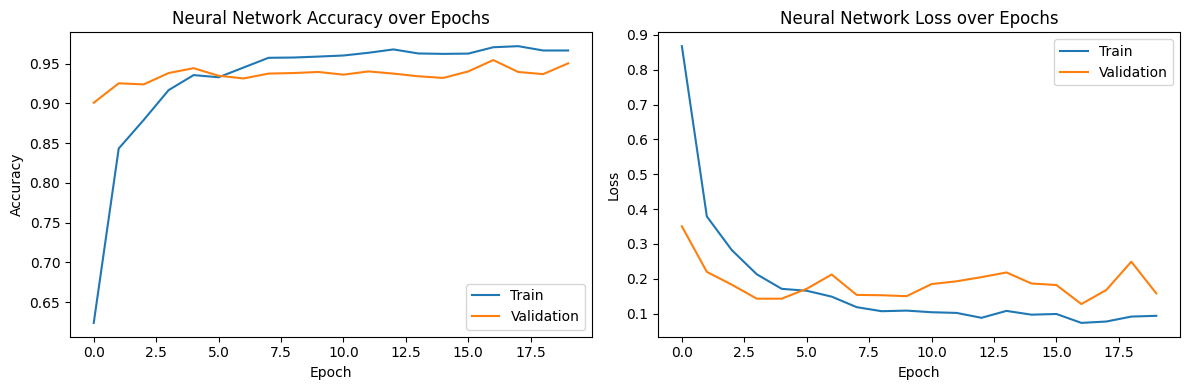

In [29]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Neural Network Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Neural Network Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

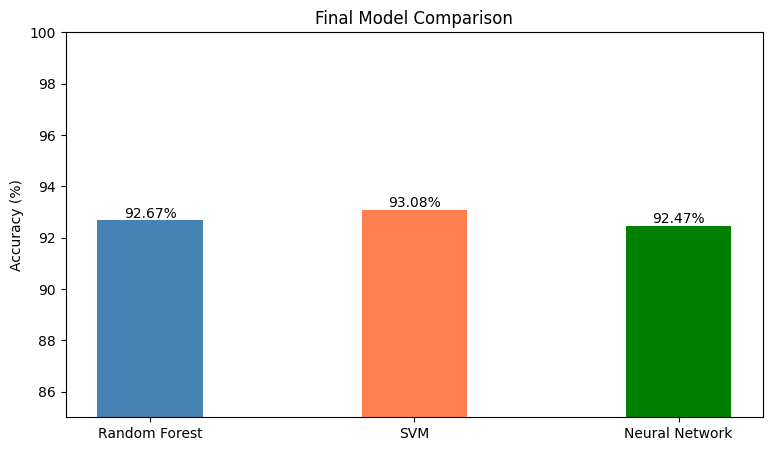

In [30]:
models = ['Random Forest', 'SVM', 'Neural Network']
accuracies = [accuracy * 100, svm_accuracy * 100, nn_accuracy * 100]

plt.figure(figsize=(9, 5))
bars = plt.bar(models, accuracies, color=['steelblue', 'coral', 'green'], width=0.4)
plt.ylim(85, 100)
plt.title('Final Model Comparison')
plt.ylabel('Accuracy (%)')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{acc:.2f}%', ha='center')
plt.show()